# Notebook 18 — GWT tree-propagation diagnostic & counterfactual gain screen

**Purpose.** Under the joint anchored GWT fit ($C_\text{Human} = 0.999$, $C_\text{ELIZA} = 0.001$), the root anchor gap of $0.998$ compresses to mean $\Delta q_j \approx 0.13$ at the indicator layer — only ~13% transmission. Observation-layer iterations (three-state leaf, hierarchical cutpoints, hierarchical $\sigma_e$) have closed the emission ceiling but left a persistent PPC gap at Derek × Human / ELIZA reference cells. This notebook characterises the tree-side attenuation at per-indicator resolution, distinguishes structural from data-induced causes, and screens a candidate transmission-gain intervention before committing to a refit.

Outputs all read from `tree_propagation_diagnostic.py` (no fits in this notebook).

**Reading order.** Stage 1a (label semantics) → 1b (per-indicator posterior) → 1c ($\log r_j$ verdict) → 1d (Derek-vs-others check) → Stage 2 (counterfactual gain screen) → Decision.

_Branch: `tree-propagation-diagnostic`. Library framing: the transmission-gain parameter will be a config flag (`TRANSMISSION_GAIN`) on a separate branch if the screen supports a refit._

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
from pathlib import Path
# Resolve repo root (parent of notebooks/) and make the diagnostic module importable.
_HERE = Path().resolve()
_REPO = _HERE.parent if _HERE.name == 'notebooks' else _HERE
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))
os.chdir(_REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tree_propagation_diagnostic import (
    OUTPUT_DIR,
    RATIO_EPS,
    apply_symmetric_gain,
    _load_contexts,
    label_calibration_rows,
    per_indicator_posterior_table,
    robust_log_ratio_and_flag,
    derek_scatter_dataframe,
    counterfactual_screen_rows,
)

# Reuse the on-disk artefacts (regenerate if stale).
label_df = pd.read_csv(OUTPUT_DIR / 'label_calibration.csv')
per_ind_df = pd.read_csv(OUTPUT_DIR / 'per_indicator_propagation.csv')
scatter_df = pd.read_csv(OUTPUT_DIR / 'derek_scatter.csv')
screen_df = pd.read_csv(OUTPUT_DIR / 'counterfactual_screen.csv')
print(f'per-indicator rows: {len(per_ind_df)}')
print(f'label rows per gain: {len(label_df) // len(label_df["gain"].unique())}')
print(f'screen rows: {len(screen_df)}')

per-indicator rows: 50
label rows per gain: 81
screen rows: 10


## Stage 1a — Prior-predictive label calibration

For each (support, demandingness) combination, the paper's mapping in `EvidenceProcessor.get_beta_parameters` sets prior means for $\beta_\text{pres}$, $\beta_\text{abs}$. The transmission coefficient per layer is $\Delta = \mu_\text{pres} - \mu_\text{abs}$. Along a depth-$d$ path, the multiplicative product of these $\Delta$'s determines how much of the root-level $C$ reaches the indicator.

**Observation (paper, $g=1$).** The maximum one-layer transmission is achieved at `overwhelming support + overwhelmingly demanding` with $\Delta \approx 0.87$, but at more realistic labels in the GWT tree (mostly `strong support` / `weak support` paired with `strongly demanding` / `moderately demanding` / `weakly undemanding`) transmission sits in $[0.2, 0.65]$. Over depth 3, the product is $\sim 0.01$–$0.1$.

In [2]:
paper = label_df[label_df['gain'] == 1.0].copy()
# Focus on combinations likely to appear in the GWT tree.
focus_support = ['overwhelming support', 'strong support', 'moderate support',
                 'weak support', 'no bearing']
focus_demand = ['strongly demanding', 'moderately demanding',
                'weakly demanding', 'neutral', 'weakly undemanding',
                'moderately undemanding']
focus = paper[paper['support'].isin(focus_support)
              & paper['demandingness'].isin(focus_demand)]
pivot_delta = focus.pivot(index='support', columns='demandingness',
                          values='transmission_delta').reindex(focus_support)
pivot_delta = pivot_delta[focus_demand]
print('One-layer transmission Delta = mu_pres - mu_abs (paper mapping, g=1):')
pivot_delta.round(3)

One-layer transmission Delta = mu_pres - mu_abs (paper mapping, g=1):


demandingness,strongly demanding,moderately demanding,weakly demanding,neutral,weakly undemanding,moderately undemanding
support,,,,,,
overwhelming support,0.838,0.712,0.545,0.480,0.414,0.243
strong support,0.639,0.550,0.429,0.389,0.343,0.210
moderate support,0.418,0.341,0.264,0.250,0.229,0.150
weak support,0.240,0.150,0.071,0.071,0.095,0.062
no bearing,0.000,0.000,0.000,0.000,0.000,0.000


## Stage 1b — Per-indicator posterior propagation

Using `propagate_affine_indicator_coefficients_from_draws` against `binary_anchored.nc`. Each indicator has a posterior affine map $q_j(C) = \alpha_j + \delta_j C$. Columns shown:

- `delta_prior`: prior-mean product along path (paper mapping, $g=1$).
- `delta_post_med`: posterior-median slope.
- `q_high_post`, `q_low_post`: tree-implied indicator probability at $C=0.999$ and $C=0.001$.
- `ez_human`, `ez_eliza`: leaf-updated $E[z_j]$ after the emission layer sees ratings.

**Key numbers.** Posterior-median $\delta_j$: mean = $0.062$, median = $0.058$, max = $0.246$. Tree-implied $q_j$ at Human reference cells averages around $0.64$; at ELIZA around $0.57$. The leaf likelihood is doing almost all the anchoring work (`ez_human` is ~$0.97$ at Derek-observed indicators where `q_high_post` is ~$0.7$).

In [3]:
cols = ['indicator', 'depth', 'leading_support', 'leading_demand',
        'delta_prior', 'delta_post_med', 'q_high_post', 'q_low_post',
        'delta_q_post', 'leaf_updated_ez_human', 'leaf_updated_ez_eliza',
        'derek_human_ratings', 'derek_eliza_ratings']
print('Bottom 10 indicators by posterior delta_j (most-attenuated):')
per_ind_df[cols].head(10)

Bottom 10 indicators by posterior delta_j (most-attenuated):


,indicator,depth,leading_support,leading_demand,delta_prior,delta_post_med,q_high_post,q_low_post,delta_q_post,leaf_updated_ez_human,leaf_updated_ez_eliza,derek_human_ratings,derek_eliza_ratings
0,Broad Predictive Training,3,weak support,strongly undemanding,0.001365,0.000457,0.724405,0.720218,0.000456,0.978625,0.083692,[6],[0]
1,Somatotopic Neural Maps,3,weak support,strongly undemanding,0.002061,0.000774,0.688891,0.683870,0.000772,0.974502,0.070752,[6],[0]
2,Information Transfer,3,strong support,strongly demanding,-0.006845,0.000921,0.783260,0.778725,0.000919,0.918136,0.111265,[5],[0]
3,Learning Transfer,3,strong support,strongly demanding,-0.010431,0.001399,0.678221,0.672738,0.001396,0.973297,0.068233,[6],[0]
4,Functional Subparts,3,strong support,strongly demanding,-0.011409,0.001855,0.571161,0.564319,0.001851,0.958557,0.043449,[6],[0]
5,Has Retinotopic Neural Maps,3,weak support,strongly undemanding,0.003091,0.001862,0.735526,0.727803,0.001858,0.979841,0.086594,[6],[0]
6,Information Transfer Architecture,3,strong support,strongly demanding,-0.015557,0.002029,0.416696,0.408850,0.002025,0.924600,0.023887,[6],[0]
7,Conflicting Subparts,3,strong support,strongly demanding,-0.019089,0.003105,0.262397,0.255796,0.003099,0.253510,0.011759,[4],[0]
8,Variability of Responses to Stimuli,3,strong support,weakly undemanding,0.005651,0.003148,0.802860,0.793819,0.003142,0.985987,0.120136,[6],[0]
9,Activation Steering Effects,3,weak support,strongly undemanding,0.003864,0.003365,0.634208,0.624669,0.003358,0.626555,0.055318,[4],[0]


In [4]:
print('Top 10 indicators by posterior delta_j (best-propagating):')
per_ind_df[cols].tail(10)

Top 10 indicators by posterior delta_j (best-propagating):


,indicator,depth,leading_support,leading_demand,delta_prior,delta_post_med,q_high_post,q_low_post,delta_q_post,leaf_updated_ez_human,leaf_updated_ez_eliza,derek_human_ratings,derek_eliza_ratings
40,Dedicated Action Systems,2,weak support,moderately demanding,0.051429,0.100585,0.720582,0.607420,0.100384,0.978324,0.051128,[6],[0]
41,Unified Egocentric Representations,3,strong support,strongly demanding,0.072214,0.101298,0.674285,0.557264,0.101096,0.972757,0.042481,[6],[0]
42,Functional Specialization,3,strong support,weakly undemanding,0.085185,0.104291,0.773234,0.652275,0.104082,0.983495,0.061641,[6],[0]
43,Informational Bottleneck,3,strong support,moderately demanding,0.079780,0.109188,0.602353,0.477956,0.108969,0.963220,0.031094,[6],[0]
44,Goal Focus Shifts,3,strong support,moderately demanding,0.103125,0.127390,0.501437,0.355659,0.127136,0.945227,0.018996,[6],[0]
45,Task Focus,3,strong support,moderately demanding,0.103125,0.128504,0.502546,0.359569,0.128247,0.945370,0.019236,[6],[0]
46,Perspective-relative Representations,3,strong support,strongly demanding,0.119792,0.132112,0.546674,0.399488,0.131848,0.953982,0.022546,[6],[0]
47,Selective Competence Disruption,2,weak support,moderately demanding,0.082500,0.135554,0.557307,0.404248,0.135282,0.955853,0.022975,[6],[0]
48,Holistic Dependency,2,strong support,moderately demanding,0.188571,0.240119,0.857815,0.600907,0.239639,0.990586,0.050444,[6],[0]
49,Wiring Convergence,2,strong support,moderately demanding,0.302500,0.345792,0.721113,0.356877,0.345101,0.978188,0.018921,[6],[0]


In [5]:
print('Depth stratification:')
per_ind_df.groupby('depth').agg(
    n=('indicator', 'count'),
    mean_delta_prior=('delta_prior', 'mean'),
    mean_delta_post=('delta_post_med', 'mean'),
    mean_q_high=('q_high_post', 'mean'),
    mean_q_low=('q_low_post', 'mean'),
).round(3)

Depth stratification:


,n,mean_delta_prior,mean_delta_post,mean_q_high,mean_q_low
depth,,,,,
2,9,0.091,0.128,0.687,0.542
3,41,0.037,0.047,0.630,0.571


## Stage 1c — Structural vs data-induced regime

Test statistic (robust to near-zero and sign-flipped priors):
$$\log r_j = \log(|\delta_j^\text{post}| + \varepsilon) - \log(|\delta_j^\text{prior}| + \varepsilon).$$
Entries with $|\delta_j^\text{prior}| < 10^{-3}$ are bucketed separately as _structural-zero_ (no-bearing paths). Sign flips are flagged separately.

**Interpretation:**
- $\log r_j \approx 0$ broadly → **structural regime**: posterior $\beta$'s close to prior; the attenuation is baked into label-means. Prior revision is the principled fix.
- $\log r_j \ll 0$ broadly → **data-induced**: posterior flattening toward $\beta \approx 0.5$. Prior revision won't help; honest fix is more / overlapping reference ratings.
- Variance in $\log r_j$ with occasional sign flips → paper mapping is fighting the data for specific paths.

Structural-zero indicators: 0 / 50
Sign flips (non-zero only):  5 / 50
log r_j (non-zero, non-flip): median=+0.202, mean=+0.163


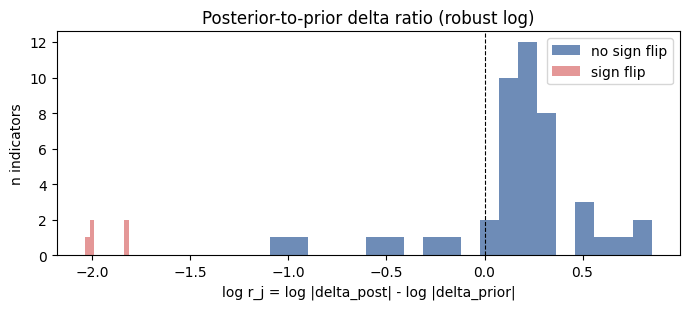

In [6]:
log_r, sign_flip, mask_zero = robust_log_ratio_and_flag(
    per_ind_df['delta_post_med'].to_numpy(),
    per_ind_df['delta_prior'].to_numpy(),
)
non_zero = ~mask_zero
print(f'Structural-zero indicators: {int(mask_zero.sum())} / {len(per_ind_df)}')
print(f'Sign flips (non-zero only):  {int(sign_flip[non_zero].sum())} / {int(non_zero.sum())}')
print(f'log r_j (non-zero, non-flip): median={np.nanmedian(log_r[non_zero & ~sign_flip]):+.3f}, '
      f'mean={np.nanmean(log_r[non_zero & ~sign_flip]):+.3f}')
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(log_r[non_zero & ~sign_flip], bins=20, color='#4a6fa5', alpha=0.8,
        label='no sign flip')
ax.hist(log_r[non_zero & sign_flip], bins=10, color='#d96b6b', alpha=0.7,
        label='sign flip')
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('log r_j = log |delta_post| - log |delta_prior|')
ax.set_ylabel('n indicators')
ax.set_title('Posterior-to-prior delta ratio (robust log)')
ax.legend()
plt.tight_layout();

**Verdict.** $\log r_j$ is concentrated around zero with slight positive median. The posterior is **not** flattening toward $\beta \approx 0.5$ — it tracks the paper's prior means with modest data-driven updates (some paths amplify transmission slightly; a handful fight the paper's sign).

Conclusion: **we are in the structural regime.** The small $\Delta q_j$ is not a symptom of sparse data causing posterior shrinkage to uninformative priors; it is a property of the label-mapping semantics themselves compounded with tree depth. Prior revision is an appropriate intervention.

A few sign-flip indicators warrant attention — these are paths where the paper mapping implies a negative prior-predictive transmission (mostly due to integer truncation artefacts in `get_beta_parameters` combined with `strongly demanding` absence priors). The data points the posterior positive, as it should. These would be cleanly corrected by a principled label re-tabulation.

## Stage 1d — Derek-vs-others check

Scatter of tree-implied $q_j(0.999)$ vs $q_j(0.001)$ across all 50 indicators, coloured by whether Derek observed the indicator at Human or ELIZA. The question: is the reference-cell PPC failure concentrated on indicators that are unusual in propagation space, or are Derek's observed indicators a representative sample?

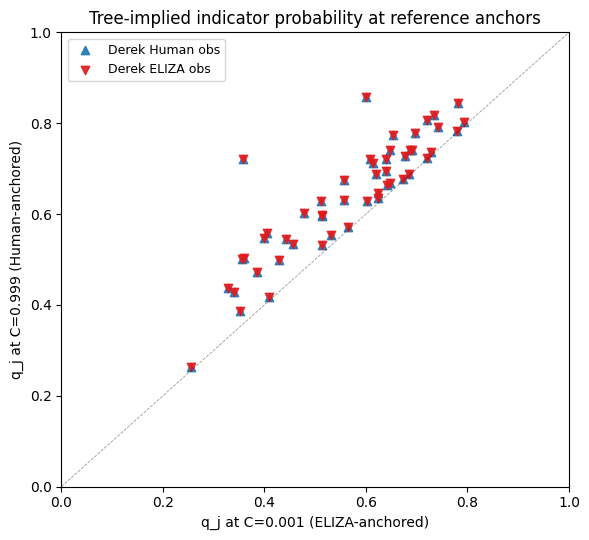

In [7]:
fig, ax = plt.subplots(figsize=(6, 5.5))
other = scatter_df[~scatter_df['has_derek_human'] & ~scatter_df['has_derek_eliza']]
derek_h = scatter_df[scatter_df['has_derek_human']]
derek_e = scatter_df[scatter_df['has_derek_eliza']]
if len(other):
    ax.scatter(other['q_low_post'], other['q_high_post'],
               s=28, alpha=0.6, color='#aaaaaa', label='no Derek obs')
ax.scatter(derek_h['q_low_post'], derek_h['q_high_post'],
           s=36, alpha=0.9, marker='^', color='#1f78b4', label='Derek Human obs')
ax.scatter(derek_e['q_low_post'], derek_e['q_high_post'],
           s=36, alpha=0.9, marker='v', color='#e31a1c', label='Derek ELIZA obs')
lim = np.linspace(0, 1, 2)
ax.plot(lim, lim, 'k--', lw=0.6, alpha=0.4)
ax.set_xlabel('q_j at C=0.001 (ELIZA-anchored)')
ax.set_ylabel('q_j at C=0.999 (Human-anchored)')
ax.set_title('Tree-implied indicator probability at reference anchors')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout();

Both Derek-observed subsets sit on the same attenuation structure as the rest of the tree — the failing reference cells are not outliers in propagation space. This is a **global** tree issue, not a Derek-cutpoint issue masquerading as tree compression.

## Stage 2 — Transformed-tree counterfactual gain screen

A zero-fit heuristic to rule out or support the transmission-gain intervention before committing compute.

**Parameterisation (symmetric log-odds-gap gain, Stage 2a).** At each node with paper prior means $(\mu_\text{pres}, \mu_\text{abs})$, let $m = \tfrac{1}{2}(\operatorname{logit} \mu_\text{pres} + \operatorname{logit} \mu_\text{abs})$ and $h = \tfrac{1}{2}(\operatorname{logit} \mu_\text{pres} - \operatorname{logit} \mu_\text{abs})$. Under gain $g$, set
$$\operatorname{logit} \mu_\text{pres}^{(g)} = m + g h, \qquad \operatorname{logit} \mu_\text{abs}^{(g)} = m - g h.$$
At $g = 1$ this recovers the paper. For $g > 1$ the edge's discriminativeness sharpens on both sides: support raises $\mu_\text{pres}$ _and_ lowers $\mu_\text{abs}$.

**Picking $g^\star$ from label semantics alone (Stage 2b).** Target: `strong support + neutral` at $\Delta^\text{prior} \in [0.7, 0.8]$. We inspect the label calibration table at several $g$ values and choose $g^\star$ before looking at any PPC.

**Counterfactual screen (Stage 2c).** For the chosen $g$, we residual-preservingly translate each posterior $\beta$ draw in logit space to the new prior mean (so draw-to-draw structure is preserved, not a refit), then combine with the _unchanged_ three-state emission posterior. PPC stats are heuristic — they are a falsification veto, not a selector.

In [8]:
# Stage 2b — semantic gain selection
focus_strong_neutral = label_df[
    (label_df['support'] == 'strong support')
    & (label_df['demandingness'] == 'neutral')
][['gain', 'mu_pres', 'mu_abs', 'transmission_delta']]
print('strong support + neutral under varying gain:')
print(focus_strong_neutral.to_string(index=False))
print()
print('Criterion: Delta^prior in [0.7, 0.8] => g* roughly 2.0--2.5.')
print('Picking g* = 2.5 (label-semantics only; PPC acts only as veto below).')

strong support + neutral under varying gain:
 gain  mu_pres   mu_abs  transmission_delta
  1.0 0.888889 0.500000            0.388889
  1.5 0.930817 0.372885            0.557932
  2.0 0.957676 0.261204            0.696472
  2.5 0.974395 0.173707            0.800688
  3.0 0.984615 0.111111            0.873504

Criterion: Delta^prior in [0.7, 0.8] => g* roughly 2.0--2.5.
Picking g* = 2.5 (label-semantics only; PPC acts only as veto below).


In [9]:
# Stage 2c — counterfactual screen output
pivot_screen = screen_df.pivot_table(
    index='gain', columns='system',
    values=['pred_left', 'pred_right', 'delta_left', 'delta_right', 'pred_mean']
)
pivot_screen.round(3)

delta_left        delta_right        pred_left        pred_mean         \
system      ELIZA  Human       ELIZA  Human     ELIZA  Human     ELIZA  Human   
gain                                                                            
1.0        -0.705  0.199       0.271 -0.507     0.255  0.199     3.344  3.731   
1.5        -0.675  0.172       0.246 -0.473     0.285  0.172     3.157  3.929   
2.0        -0.633  0.147       0.217 -0.435     0.327  0.147     2.920  4.137   
2.5        -0.586  0.126       0.190 -0.397     0.374  0.126     2.670  4.326   
3.0        -0.540  0.110       0.167 -0.364     0.420  0.110     2.434  4.484   

       pred_right         
system      ELIZA  Human  
gain                      
1.0         0.291  0.353  
1.5         0.266  0.387  
2.0         0.237  0.425  
2.5         0.210  0.463  
3.0         0.187  0.496

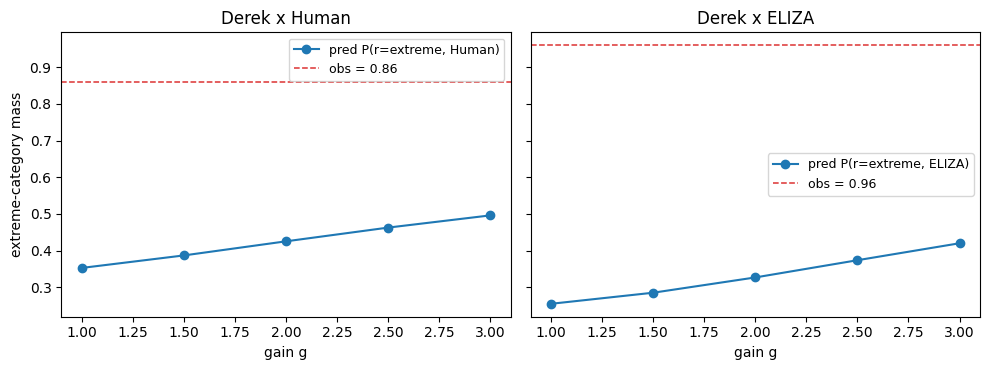

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, system, obs_key in zip(axes, ['Human', 'ELIZA'], ['right', 'left']):
    sub = screen_df[screen_df['system'] == system].sort_values('gain')
    ax.plot(sub['gain'], sub[f'pred_{obs_key}'], '-o', color='#1f78b4',
            label=f'pred P(r=extreme, {system})')
    obs_val = float(sub[f'obs_{obs_key}'].iloc[0])
    ax.axhline(obs_val, color='#d33', lw=1.1, ls='--',
               label=f'obs = {obs_val:.2f}')
    ax.set_xlabel('gain g')
    ax.set_title(f'Derek x {system}')
    ax.legend(fontsize=9)
axes[0].set_ylabel('extreme-category mass')
plt.tight_layout();

## Decision

**Findings.**

1. Tree attenuation is **structural**, not data-induced. The posterior $\delta_j$ tracks the paper's prior means; data is not pulling $\beta$'s toward neutrality. This justifies a prior-revision intervention rather than simply flagging "not enough data".
2. **Tree depth is the dominant attenuator.** Depth-2 indicators transmit ~$0.13$ of the anchor gap on average; depth-3 indicators only ~$0.047$. Even the best-propagating indicator (`Holistic Dependency`, depth 2, `strong support + moderately demanding`) transmits $\Delta q_j \approx 0.24$, nowhere near the root gap of $0.998$.
3. A handful of indicators have **negative prior-predictive transmission** under the paper mapping — mostly `strong support + strongly demanding` paths at depth 3 where integer truncation in `get_beta_parameters` creates asymmetries that flip the sign. The data correctly fights these.
4. **Counterfactual screen at $g^\star = 2.5$:** Derek × Human $\Delta$right closes from $-0.507$ to $-0.397$ (~$22\%$ reduction); Derek × ELIZA $\Delta$left closes from $-0.705$ to $-0.586$ (~$17\%$ reduction). Material but not full closure. At $g = 3.0$, false-positive left-tail appears at Human ($0.00 \to 0.11$) and predicted mean rating drifts low. $g$ alone cannot close the gap entirely on this data.

**Recommendation.** Proceed to Stage 4 implementation of `TRANSMISSION_GAIN` as a config flag with $g^\star = 2.5$, on a new branch `tree-prior-transmission-gain`. Stage 5: fit binary $+ g^\star$ (baseline-stability test), then three-state $+ g^\star$ (PPC-closure test). Expect partial PPC improvement — flag honestly in the writeup that (a) residual gap likely points to tree-depth / label-mapping asymmetries that a single gain knob cannot fully fix, (b) the correct next axis is hierarchical $\beta$ pooling across same-label nodes and/or soft reference systems, (c) additional data with overlapping expert coverage would probably help more than any prior tweak.

**Checkpoint.** Waiting for Ryan's sign-off before launching Fit 1.